<a href="https://colab.research.google.com/github/gokila-a/Stroke_Prediction_Using_TensorFlow/blob/main/Stroke_Prediction_Using_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
x=df.drop('stroke',axis=1)
y=df['stroke']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

# Drop 'id' column from both train and test sets as it's not a feature
x_train = x_train.drop('id', axis=1)
x_test = x_test.drop('id', axis=1)

# Store the mean of bmi from x_train before any modifications for consistent imputation in x_test
x_train_original_bmi_mean = x_train['bmi'].mean()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train_df = x_train.copy() # Work on a copy to avoid modifying the original split x_train
x_train_df['bmi'].fillna(x_train_df['bmi'].mean(), inplace=True)
categorical_cols = x_train_df.select_dtypes(include=['object']).columns
x_train_df = pd.get_dummies(x_train_df, columns=categorical_cols, drop_first=True)
x_train_cols = x_train_df.columns.tolist() # Store column names after one-hot encoding
x_train = scaler.fit_transform(x_train_df) # x_train becomes a numpy array after scaling

/tmp/ipykernel_1269/572710325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_df['bmi'].fillna(x_train_df['bmi'].mean(), inplace=True)


In [ ]:
print(x_train)

[[ 1.58415472 -0.32198091 -0.23618875 ...  2.17751533 -0.76412186
  -0.42923306]
 [ 0.82970766 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
  -0.42923306]
 [-0.98984115 -0.32198091 -0.23618875 ... -0.45923902  1.30869178
  -0.42923306]
 ...
 [-1.87032526 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
  -0.42923306]
 [ 1.62853396 -0.32198091 -0.23618875 ...  2.17751533 -0.76412186
  -0.42923306]
 [ 0.11963983 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
   2.32973667]]


In [ ]:
x_test_df = x_test.copy() # Work on a copy to avoid modifying the original split x_test
x_test_df['bmi'].fillna(x_train_original_bmi_mean, inplace=True) # Use mean from training set
categorical_cols_test = x_test_df.select_dtypes(include=['object']).columns
x_test_df = pd.get_dummies(x_test_df, columns=categorical_cols_test, drop_first=True)

# Ensure columns match training set after one-hot encoding
missing_cols = set(x_train_cols) - set(x_test_df.columns)
for c in missing_cols:
    x_test_df[c] = 0
# Reorder x_test_df columns to match x_train_cols
x_test_df = x_test_df[x_train_cols]

x_test = scaler.transform(x_test_df) # x_test becomes a numpy array after scaling
print(x_test)

[[-0.54604876 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
  -0.42923306]
 [-0.14663561 -0.32198091 -0.23618875 ... -0.45923902  1.30869178
  -0.42923306]
 [-1.56677126 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
  -0.42923306]
 ...
 [ 0.25277755  3.10577419 -0.23618875 ...  2.17751533 -0.76412186
  -0.42923306]
 [ 0.56343222 -0.32198091 -0.23618875 ... -0.45923902 -0.76412186
   2.32973667]
 [ 1.53977548  3.10577419  4.23390197 ... -0.45923902  1.30869178
  -0.42923306]]


/tmp/ipykernel_1269/3456603033.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test_df['bmi'].fillna(x_train_original_bmi_mean, inplace=True) # Use mean from training set


In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)), #flatten- to convert 1 dimensional arr, 30 columns,features
    keras.layers.Dense(20, activation='relu'),#dense- hidden layer,here 20 hidden layer
    keras.layers.Dense(2,activation='sigmoid')#2 output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(15,)), # Corrected input_shape to 15 features based on x_train_cols
    keras.layers.Dense(20, activation='relu'), # Dense - hidden layer, here 20 hidden layer
    keras.layers.Dense(1, activation='sigmoid') # 1 output unit for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy', # Changed to binary_crossentropy for binary classification
              metrics=['accuracy'])

history = model.fit(x_train, y_train, validation_split=0.1, epochs=90)

Epoch 1/90


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6080 - loss: 0.6771 - val_accuracy: 0.9022 - val_loss: 0.4377
Epoch 2/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9293 - loss: 0.3437 - val_accuracy: 0.9487 - val_loss: 0.2702
Epoch 3/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9543 - loss: 0.2282 - val_accuracy: 0.9487 - val_loss: 0.2091
Epoch 4/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1859 - val_accuracy: 0.9487 - val_loss: 0.1907
Epoch 5/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1714 - val_accuracy: 0.9487 - val_loss: 0.1848
Epoch 6/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1652 - val_accuracy: 0.9487 - val_loss: 0.1820
Epoch 7/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1616 - val_accuracy: 0.9487 - val_loss: 0.1800
Epoch 8/90
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1590 - val_accuracy: 0.9487 - val_

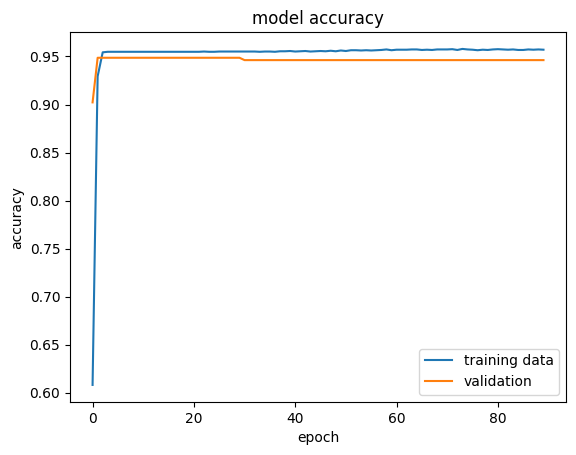

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data','validation'],loc= 'lower right')

In [ ]:
plt.show()

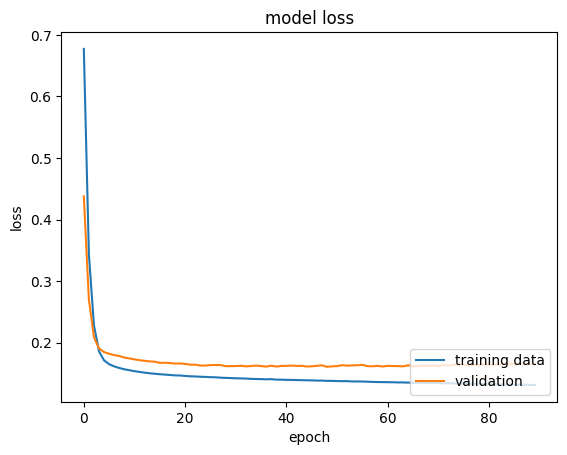

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data','validation'],loc= 'lower right')